# 🛡️ ChainGuard: Multi-Chain Threat Intelligence & Model Engineering Pipeline

Welcome to the **ChainGuard Pipeline Notebook**. This notebook executes multi-chain cryptocurrency threat detection and fund-flow tracing across.

---

### 📌 Pipeline Phases:
1. **Phase 1 — Environment Setup & Core Dependencies:** Initializing system libraries.
2. **Phase 2 — Data Ingestion & Dataset Discovery:** Loading BitcoinHeist & Elliptic datasets.
3. **Phase 3 — Exploratory Data Analysis (EDA):** Class distributions, feature correlations, and behavioral boxplots.
4. **Phase 4 — Behavioral Feature Engineering:** Ratio features, log transforms, and address behavior profiles.
5. **Phase 5 — Schema Normalization:** Normalizing UTXO (BTC/LTC) and Account (ETH) feeds.
6. **Phase 6 — Tabular Ransomware Models:** Benchmarking DecisionTree, LogisticRegression, RandomForest, XGBoost, and Deep MLP.
7. **Phase 7 — Temporal Transaction GNN Models:** PyTorch GNN benchmark (MLP, GCN, GraphSAGE, Deep ResGraphSAGE).
8. **Phase 8 — Unsupervised Anomaly Detection:** Isolation Forest and Local Outlier Factor scoring.
9. **Phase 9 — Graph Fund-Flow Tracing:** Address clustering, fund traversal, and peel-chain detection.
10. **Phase 10 — Model Export & REST Serving API:** Exporting model artifacts and querying production inference engine.

## Phase 1: Environment Setup & Core Dependencies

Importing core numerical, modeling, and visualization libraries.

In [1]:
import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, auc

# Set visualization styling
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 10.5

# Determine project root directory dynamically (supports running from root or notebooks/ directory)
current_dir = os.path.abspath('')
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

# Set absolute directories for visualizations and exported models
viz_dir = os.path.join(project_root, 'visualizations')
export_dir = os.path.join(project_root, 'exported_models')
os.makedirs(viz_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

# Add project root directory to Python path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import core ChainGuard modules
from src.data_loading import load_bitcoinheist, load_elliptic
from src.features import bitcoinheist_features, address_behavior_profile
from src.models.ransomware_model import RansomwareClassifier, RansomwareModelSuite
from src.models.elliptic_gnn import EllipticGNNPipeline, GraphSAGEModel, GCNModel, MLPGraphModel, DeepResGraphSAGEModel
from src.graph_analysis import build_flow_graph, trace_fund_flow, detect_peel_chain, detect_fan_out_fan_in, common_input_clustering
from src.anomaly_detection import IsolationForestDetector, LocalOutlierFactorDetector, behavioral_change_score
from src.risk_scoring import RiskAssessment
from src.multichain_pipeline import normalize_utxo_chain, normalize_account_chain, merge_chains
from src.model_serving import ModelRegistry, InferenceEngine

print('✅ Phase 1 Complete: All dependencies and ChainGuard modules successfully initialized.')

✅ Phase 1 Complete: All dependencies and ChainGuard modules successfully initialized.


## Phase 2: Data Ingestion & Dataset Discovery

Loading and inspecting BitcoinHeist and Elliptic datasets.

In [2]:
# Load sampled BitcoinHeist data
bh_df = load_bitcoinheist(sample_size=15000)
print('BitcoinHeist Data Shape:', bh_df.shape)
display(bh_df.head(3))

# Load sampled Elliptic dataset
features_df, classes_df, edgelist_df = load_elliptic(sample_size=15000)
print('\nElliptic Features Shape:', features_df.shape)
print('Elliptic Edges Count:', len(edgelist_df))
display(classes_df.head(3))

print('✅ Phase 2 Complete: Datasets successfully loaded and inspected.')

[data_loading] Loading BitcoinHeist dataset from Dataset/Bitcoin Heist Ransomware Address/BitcoinHeistData.csv...


[data_loading] BitcoinHeist loaded: 15,000 rows. Ransomware samples: 203
BitcoinHeist Data Shape: (15000, 11)


,address,year,day,length,weight,count,looped,neighbors,income,label,is_ransomware
0,15DQFhP5R7ZeaBS9Ute7NzrYVBFSH1Z2kZ,2018,82,8,1.311111,3,0,2,577264100.0,white,0
1,3FhUXgmVecach9dZ59JK1yBLEcr9JsvJXZ,2016,157,2,0.025000,44,0,1,100000000.0,white,0
2,3DpHZaCtj88yaXUtajYnYLb8xgN15K8fnw,2018,118,144,3.619217,5991,5991,2,299950000.0,white,0


[data_loading] Loading Elliptic dataset from Dataset/Elliptic...


[data_loading] Sampling Elliptic dataset to 15,000 transactions...
[data_loading] Elliptic loaded: 15,000 transactions, 1,269 edges. Illicit: 343, Licit: 3,102, Unknown: 11,555

Elliptic Features Shape: (15000, 167)
Elliptic Edges Count: 1269


,txId,class,class_mapped
0,230460314,unknown,-1
1,230333930,unknown,-1
2,36411953,unknown,-1


✅ Phase 2 Complete: Datasets successfully loaded and inspected.


## Phase 3: Exploratory Data Analysis (EDA) & Data Profiling

Computing feature correlation matrix and income distribution boxplots.

/tmp/ipykernel_40655/4105197516.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bh_feat, x='is_ransomware', y='income_per_neighbor', palette=['#2563EB', '#DC2626'], ax=axes[1])
/tmp/ipykernel_40655/4105197516.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['White (Legit)', 'Ransomware'])


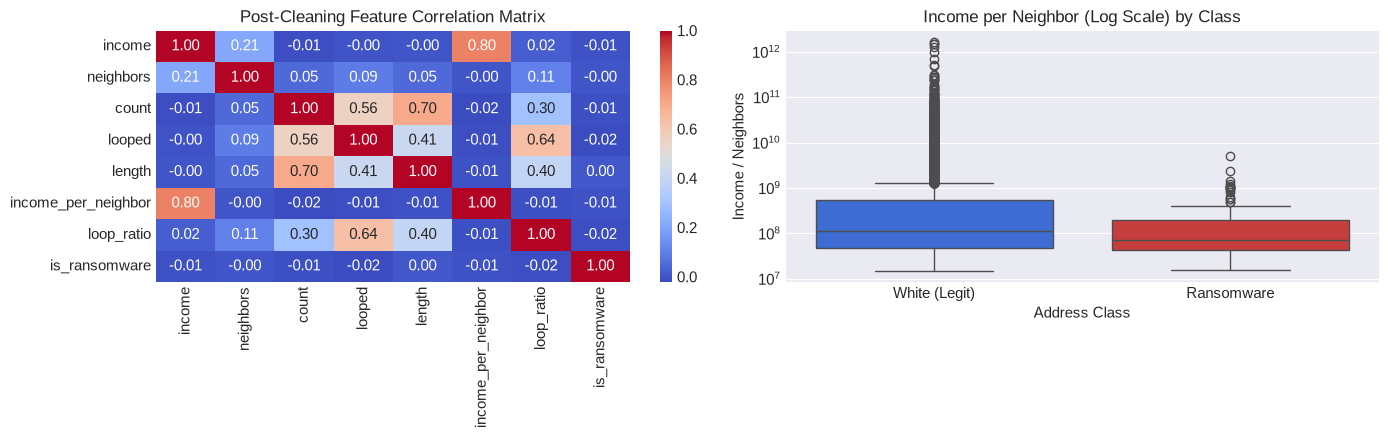

✅ Phase 3 Complete: EDA plots rendered and exported.


In [3]:
bh_feat = bitcoinheist_features(bh_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 1. Feature Correlation Matrix
corr_cols = ['income', 'neighbors', 'count', 'looped', 'length', 'income_per_neighbor', 'loop_ratio', 'is_ransomware']
corr_matrix = bh_feat[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], cbar=True)
axes[0].set_title('Post-Cleaning Feature Correlation Matrix')

# 2. Income per Neighbor Boxplot
sns.boxplot(data=bh_feat, x='is_ransomware', y='income_per_neighbor', palette=['#2563EB', '#DC2626'], ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xticklabels(['White (Legit)', 'Ransomware'])
axes[1].set_title('Income per Neighbor (Log Scale) by Class')
axes[1].set_xlabel('Address Class')
axes[1].set_ylabel('Income / Neighbors')

plt.tight_layout()
corr_img_path = os.path.join(viz_dir, 'post_cleaning_correlations.png')
plt.savefig(corr_img_path, dpi=200, bbox_inches='tight')
plt.show()
print('✅ Phase 3 Complete: EDA plots rendered and exported.')

## Phase 4: Behavioral Feature Engineering & Address Profiling

Engineering ratio features (, ), log transformations, and address behavioral profiles.

In [4]:
print('Engineered BitcoinHeist Columns:')
engineered_cols = [c for c in bh_feat.columns if c not in bh_df.columns]
print(engineered_cols)
display(bh_feat[['address', 'income', 'neighbors', 'income_per_neighbor', 'loop_ratio', 'log_income']].head(3))

# Generate Address Behavior Profile
sample_txs = pd.DataFrame({
    'chain': ['BTC', 'BTC', 'BTC'],
    'tx_hash': ['tx1', 'tx2', 'tx3'],
    'from_address': ['addrA', 'addrA', 'addrB'],
    'to_address': ['addrB', 'addrC', 'addrC'],
    'amount': [10.0, 5.0, 12.0],
    'timestamp': [1000, 2000, 3000]
})
profile = address_behavior_profile(sample_txs)
display(profile)
print('✅ Phase 4 Complete: Behavioral feature extraction successful.')

Engineered BitcoinHeist Columns:
['income_per_neighbor', 'income_per_count', 'loop_ratio', 'weight_per_count', 'length_per_count', 'log_income', 'log_weight', 'log_count', 'log_neighbors', 'temporal_day']


,address,income,neighbors,income_per_neighbor,loop_ratio,log_income
0,15DQFhP5R7ZeaBS9Ute7NzrYVBFSH1Z2kZ,577264100.0,2,2.886306e+08,0.0,20.173810
1,3FhUXgmVecach9dZ59JK1yBLEcr9JsvJXZ,100000000.0,1,9.999900e+07,0.0,18.420681
2,3DpHZaCtj88yaXUtajYnYLb8xgN15K8fnw,299950000.0,2,1.499743e+08,1.0,19.519126


,address,sent_count,sent_amount_sum,sent_amount_mean,sent_amount_std,unique_destinations,min_sent_time,max_sent_time,received_count,received_amount_sum,...,min_recv_time,max_recv_time,tx_count,total_volume,net_flow,fan_out_ratio,fan_in_ratio,out_in_count_ratio,active_duration_sec,tx_velocity_per_hour
0,addrA,2.0,15.0,7.5,3.535534,2.0,1000.0,2000.0,0.0,0.0,...,0.0,0.0,2.0,15.0,-15.0,0.999995,0.000000,200000.00000,2000.0,1.285714
1,addrB,1.0,12.0,12.0,0.000000,1.0,3000.0,3000.0,1.0,10.0,...,1000.0,1000.0,2.0,22.0,-2.0,0.999990,0.999990,0.99999,2000.0,1.285714
2,addrC,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,17.0,...,2000.0,3000.0,2.0,17.0,17.0,0.000000,0.999995,0.00000,3000.0,1.090909


✅ Phase 4 Complete: Behavioral feature extraction successful.


## Phase 5: Multi-Chain Feeds & Schema Normalization

Normalizing UTXO (BTC/LTC) and Account (ETH) feeds into a unified transaction stream schema.

In [5]:
raw_utxo = pd.DataFrame({
    'address': ['1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa'],
    'income': [5000000000.0],
    'year': [2009],
    'day': [3]
})

raw_eth = pd.DataFrame({
    'hash': ['0xabc123456789def'],
    'from': ['0x71C7656EC7ab88b098defB751B7401B5f6d8976F'],
    'to': ['0x1111111111111111111111111111111111111111'],
    'value': [1.5],
    'gas_price': [0.00002],
    'time': [1600000000]
})

norm_btc = normalize_utxo_chain(raw_utxo, chain_name='BTC')
norm_eth = normalize_account_chain(raw_eth, chain_name='ETH')
merged_stream = merge_chains([norm_btc, norm_eth])

print('Unified Multi-Chain Stream:')
display(merged_stream)
print('✅ Phase 5 Complete: Multi-chain normalization verified.')

Unified Multi-Chain Stream:


,chain,tx_hash,from_address,to_address,amount,fee,timestamp
0,BTC,btc_tx_0000000,1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa,sink_6571,5.000000e+09,0.00000,259200
1,ETH,0xabc123456789def,0x71C7656EC7ab88b098defB751B7401B5f6d8976F,0x1111111111111111111111111111111111111111,1.500000e+00,0.00002,1600000000


✅ Phase 5 Complete: Multi-chain normalization verified.


## Phase 6: Tabular Ransomware Models

Training and benchmarking tabular classification models (, , , , ).

Executing Tabular Model Benchmark...


,Model,Model Tier,Precision,Recall,F1 Score,PR-AUC,ROC-AUC,Latency (ms/sample),Train Time (s)
0,XGBoost,Large,0.353043,1.000000,0.521851,0.932616,0.998846,0.0013,2.228
1,RandomForest,Medium,0.089888,0.985222,0.164745,0.631893,0.982053,0.0023,0.263
2,Deep MLP NeuralNet,Deep,0.962264,0.251232,0.398438,0.497186,0.945283,0.0019,13.630
3,DecisionTree,Small,0.023285,0.822660,0.045288,0.065913,0.724917,0.0001,0.042
4,LogisticRegression,Small,0.023895,0.719212,0.046254,0.026706,0.706650,0.0000,0.082


[RansomwareModelSuite] Exported 5 models to /home/mrradix/Projects/ChainGuard/exported_models


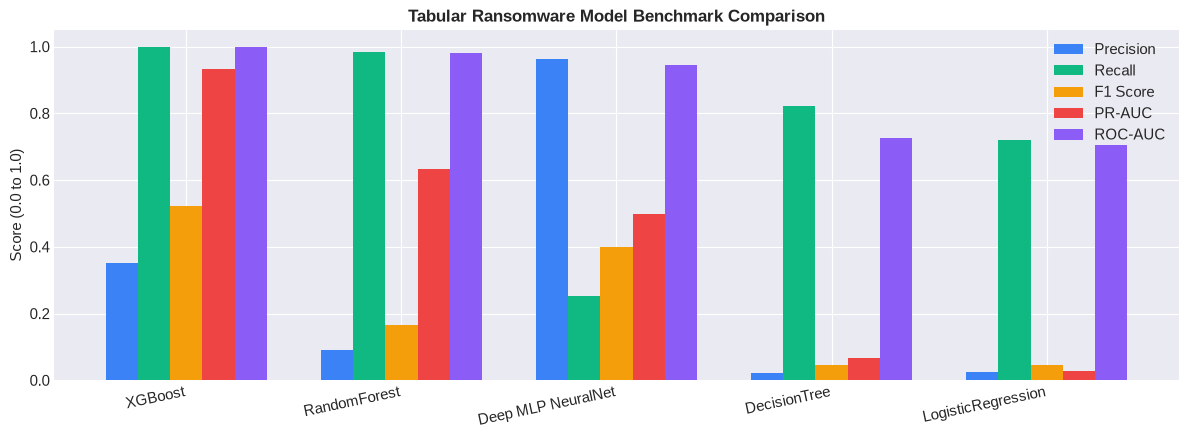

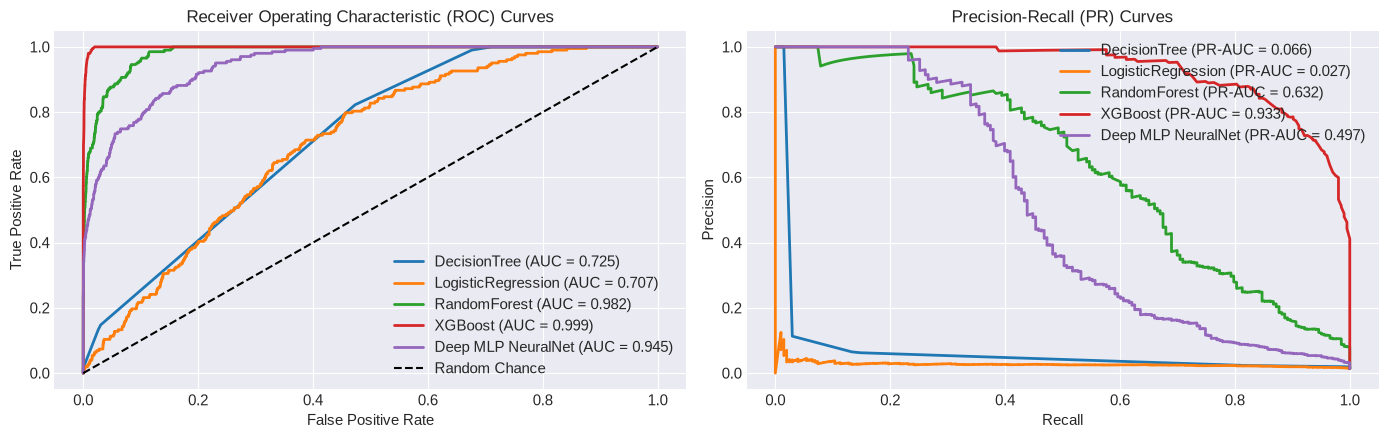

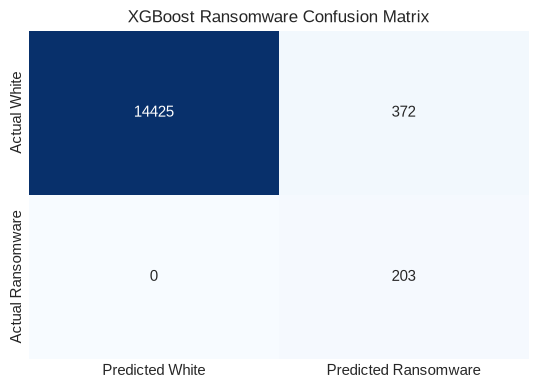

✅ Phase 6 Complete: Tabular spectrum benchmarked, plotted, and exported.


In [6]:
print('Executing Tabular Model Benchmark...')
tabular_suite = RansomwareModelSuite()
tab_benchmarks = tabular_suite.train_and_benchmark(train_df=bh_df)
display(tab_benchmarks)

# Export trained tabular models
tab_exports = tabular_suite.export_models(export_dir)

# 1. Render Grouped Tabular Benchmark Bar Chart
fig, ax = plt.subplots(figsize=(12, 4.5))
models = tab_benchmarks['Model'].tolist()
metrics = ['Precision', 'Recall', 'F1 Score', 'PR-AUC', 'ROC-AUC']
x = np.arange(len(models))
width = 0.15
colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']

for i, metric in enumerate(metrics):
    values = tab_benchmarks[metric].values
    ax.bar(x + (i - 2) * width, values, width, label=metric, color=colors[i])

ax.set_title('Tabular Ransomware Model Benchmark Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=12, ha='right')
ax.set_ylabel('Score (0.0 to 1.0)')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
plt.tight_layout()
tab_chart_path = os.path.join(viz_dir, 'tabular_model_benchmark_chart.png')
plt.savefig(tab_chart_path, dpi=200, bbox_inches='tight')
plt.show()

# 2. Render ROC & PR Curves Plot
X_test, y_test = tabular_suite._prepare(bh_df)
X_test_scaled = tabular_suite.scaler.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, model in tabular_suite.models.items():
    if name in ['LogisticRegression', 'Deep MLP NeuralNet']:
        y_probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.3f})', linewidth=2)

    prec, rec, _ = precision_recall_curve(y_test, y_probs)
    pr_auc_val = auc(rec, prec)
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC = {pr_auc_val:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].set_title('Precision-Recall (PR) Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.tight_layout()
roc_pr_img_path = os.path.join(viz_dir, 'ransomware_roc_pr_curves.png')
plt.savefig(roc_pr_img_path, dpi=200, bbox_inches='tight')
plt.show()

# 3. Render Confusion Matrix Heatmap
best_xgb = tabular_suite.models['XGBoost']
y_preds = (best_xgb.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_preds)

fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Predicted White', 'Predicted Ransomware'],
            yticklabels=['Actual White', 'Actual Ransomware'])
ax.set_title('XGBoost Ransomware Confusion Matrix')
plt.tight_layout()
cm_img_path = os.path.join(viz_dir, 'model_confusion_matrix.png')
plt.savefig(cm_img_path, dpi=200, bbox_inches='tight')
plt.show()
print('✅ Phase 6 Complete: Tabular spectrum benchmarked, plotted, and exported.')

## Phase 7: Temporal Transaction GNN Models (PyTorch)

Benchmarking graph models (, , , ) on Elliptic temporal test split ($\ge 40$).

Benchmarking Graph GNN Models on Elliptic Temporal Split...


,Model,Model Tier,Precision,Recall,F1 Score,PR-AUC,ROC-AUC,Latency (ms/sample),Train Time (s)
0,Deep ResGraphSAGE,Deep,0.150442,0.755556,0.250923,0.418065,0.869913,0.0035,0.090
1,GraphSAGE,Large,0.134921,0.755556,0.228956,0.396907,0.836871,0.0018,0.055
2,MLP Baseline,Small,0.121622,0.800000,0.211144,0.436226,0.859675,0.0012,0.234
3,GCN,Medium,0.114198,0.822222,0.200542,0.427338,0.839173,0.0022,0.071


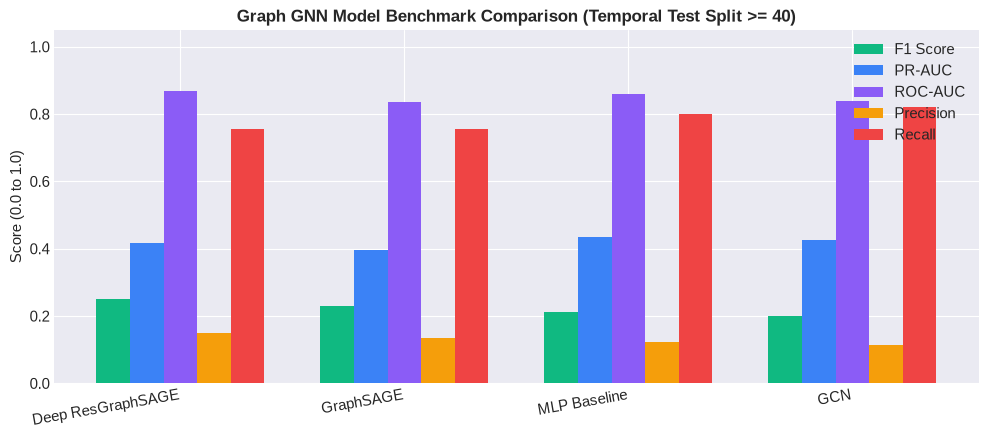

/home/mrradix/Projects/ChainGuard/src/models/elliptic_gnn.py:28: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if edge_index.size(1) == 0:


[EllipticGNNPipeline] TorchScript model exported to /home/mrradix/Projects/ChainGuard/exported_models/elliptic_graphsage.ptc


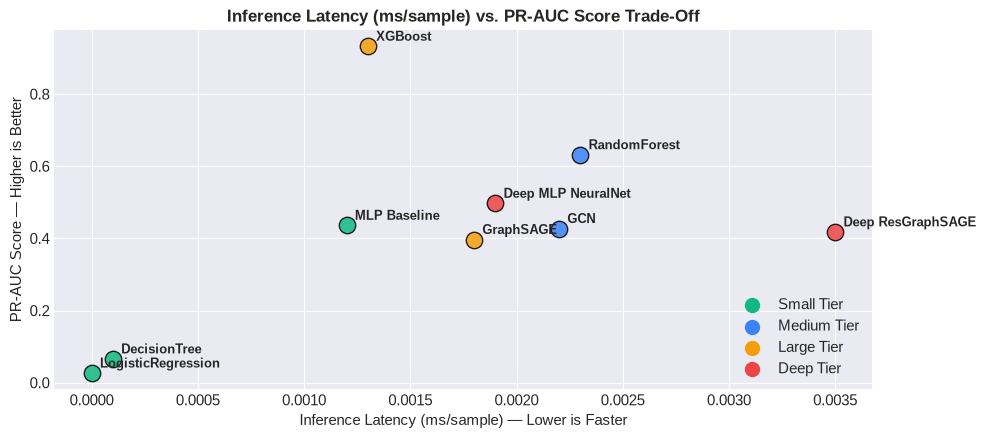

✅ Phase 7 Complete: GNN spectrum benchmarked, plotted, and exported to TorchScript.


In [7]:
print('Benchmarking Graph GNN Models on Elliptic Temporal Split...')
gnn_pipeline = EllipticGNNPipeline(hidden_dim=32, lr=0.01)
gnn_data = gnn_pipeline.prepare_data(features_df, classes_df, edgelist_df)

gnn_benchmarks = gnn_pipeline.benchmark_models(gnn_data, epochs=15)
display(gnn_benchmarks)

# Render GNN Benchmark Bar Chart
fig, ax = plt.subplots(figsize=(10, 4.5))
gnn_models = gnn_benchmarks['Model'].tolist()
gnn_metrics = ['F1 Score', 'PR-AUC', 'ROC-AUC', 'Precision', 'Recall']
x_gnn = np.arange(len(gnn_models))
w_gnn = 0.15
g_colors = ['#10B981', '#3B82F6', '#8B5CF6', '#F59E0B', '#EF4444']

for i, metric in enumerate(gnn_metrics):
    vals = gnn_benchmarks[metric].values
    ax.bar(x_gnn + (i - 2) * w_gnn, vals, w_gnn, label=metric, color=g_colors[i])

ax.set_title('Graph GNN Model Benchmark Comparison (Temporal Test Split >= 40)', fontsize=12, fontweight='bold')
ax.set_xticks(x_gnn)
ax.set_xticklabels(gnn_models, rotation=10, ha='right')
ax.set_ylabel('Score (0.0 to 1.0)')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
plt.tight_layout()
gnn_chart_path = os.path.join(viz_dir, 'gnn_model_benchmark_chart.png')
plt.savefig(gnn_chart_path, dpi=200, bbox_inches='tight')
plt.show()

# Export PyTorch GNN to TorchScript (.ptc)
ts_path = gnn_pipeline.export_torchscript(export_dir, in_features=gnn_data['num_features'])

# Render Latency vs. Accuracy Trade-Off Chart
fig, ax = plt.subplots(figsize=(10, 4.5))
combined_bench = pd.concat([
    tab_benchmarks[['Model', 'Model Tier', 'PR-AUC', 'Latency (ms/sample)']],
    gnn_benchmarks[['Model', 'Model Tier', 'PR-AUC', 'Latency (ms/sample)']]
], ignore_index=True)
tier_colors = {'Small': '#10B981', 'Medium': '#3B82F6', 'Large': '#F59E0B', 'Deep': '#EF4444'}

for _, row in combined_bench.iterrows():
    c = tier_colors.get(row['Model Tier'], '#6B7280')
    ax.scatter(row['Latency (ms/sample)'], row['PR-AUC'], color=c, s=140, alpha=0.85, edgecolors='black')
    ax.annotate(row['Model'], (row['Latency (ms/sample)'], row['PR-AUC']),
                xytext=(6, 4), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_title('Inference Latency (ms/sample) vs. PR-AUC Score Trade-Off', fontsize=12, fontweight='bold')
ax.set_xlabel('Inference Latency (ms/sample) — Lower is Faster')
ax.set_ylabel('PR-AUC Score — Higher is Better')
for tier, color in tier_colors.items():
    ax.scatter([], [], color=color, label=f'{tier} Tier', s=100)
ax.legend(loc='lower right')
plt.tight_layout()
latency_chart_path = os.path.join(viz_dir, 'latency_vs_accuracy_tradeoff.png')
plt.savefig(latency_chart_path, dpi=200, bbox_inches='tight')
plt.show()
print('✅ Phase 7 Complete: GNN spectrum benchmarked, plotted, and exported to TorchScript.')

## Phase 8: Multi-Algorithm Unsupervised Anomaly Intelligence

Executing Isolation Forest and Local Outlier Factor anomaly scoring across behavioral features.

In [8]:
bh_profile = address_behavior_profile(normalize_utxo_chain(bh_df, chain_name='BTC'))

if_det = IsolationForestDetector(contamination=0.05).fit(bh_profile)
bh_profile['if_anomaly_score'] = if_det.predict_anomaly_score(bh_profile)

lof_det = LocalOutlierFactorDetector(contamination=0.05).fit(bh_profile)
bh_profile['lof_anomaly_score'] = lof_det.predict_anomaly_score(bh_profile)

print('Unsupervised Anomaly Scores Sample:')
display(bh_profile[['address', 'tx_count', 'total_volume', 'if_anomaly_score', 'lof_anomaly_score']].head(5))
print('✅ Phase 8 Complete: Unsupervised anomaly intelligence executed.')

[IsolationForestDetector] Model fitted on 22,690 samples.


Unsupervised Anomaly Scores Sample:


,address,tx_count,total_volume,if_anomaly_score,lof_anomaly_score
0,1126JRpTbeWyTdRPxpA5n8QjxUPBGMbQ3z,1.0,8.850000e+08,0.117975,0.000041
1,112DreZDsLAmGxgS1cFkCpYEq9o1U42xAm,1.0,1.940000e+08,0.297244,0.000029
2,112JtAjcVJgnFfT3LCjewqw1axs7VdqcYT,1.0,9.018152e+09,0.338983,0.000053
3,112KGQh9oiJCuNj8ioxBh6q4dmuEvtM9AV,1.0,9.833991e+07,0.030267,0.000199
4,112LJvmwvSCtnJXBXE4T8uU9oU3PRVW3Dd,1.0,5.548066e+07,0.114712,0.000056


✅ Phase 8 Complete: Unsupervised anomaly intelligence executed.


## Phase 9: Graph Fund-Flow Tracing & Obfuscation Detectors

Tracing multi-hop fund movements, address clustering, and peel-chain obfuscation patterns.

Detected Peel Chain Pattern: [{'start_address': 'A', 'length': 3, 'hops': [{'from_address': 'A', 'main_pass_to': 'B', 'main_amount': 10.0, 'peeled_to': 'X1', 'peeled_amount': 1.2, 'peel_ratio': 0.10714285714285715}, {'from_address': 'B', 'main_pass_to': 'C', 'main_amount': 8.8, 'peeled_to': 'X2', 'peeled_amount': 1.0, 'peel_ratio': 0.1020408163265306}, {'from_address': 'C', 'main_pass_to': 'D', 'main_amount': 7.8, 'peeled_to': 'X3', 'peeled_amount': 0.9, 'peel_ratio': 0.10344827586206898}], 'total_peeled_amount': 3.1}]


,depth,from_address,to_address,amount,cumulative_amount,timestamp,chain,tx_hash,path
0,1,A,B,10.0,10.0,100.0,BTC,tx_0,"[A, B]"
1,1,A,X1,1.2,1.2,100.0,BTC,tx_1,"[A, X1]"
2,2,B,C,8.8,18.8,200.0,BTC,tx_2,"[A, B, C]"
3,2,B,X2,1.0,11.0,200.0,BTC,tx_3,"[A, B, X2]"
4,3,C,D,7.8,26.6,300.0,BTC,tx_4,"[A, B, C, D]"
5,3,C,X3,0.9,19.7,300.0,BTC,tx_5,"[A, B, C, X3]"


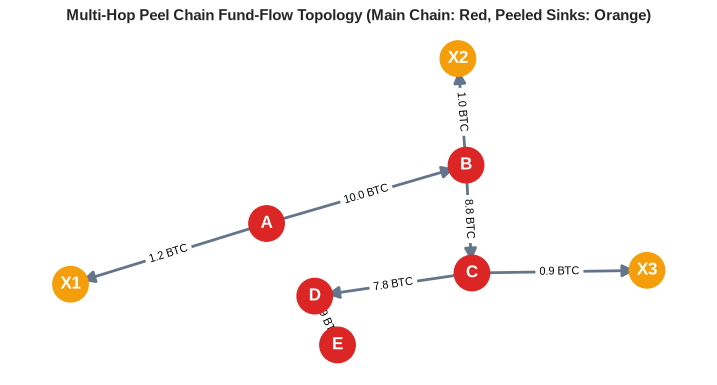

✅ Phase 9 Complete: Graph fund-flow traversal and peel chain network rendered.


In [9]:
demo_txs = pd.DataFrame({
    'from_address': ['A', 'A', 'B', 'B', 'C', 'C', 'D'],
    'to_address': ['B', 'X1', 'C', 'X2', 'D', 'X3', 'E'],
    'amount': [10.0, 1.2, 8.8, 1.0, 7.8, 0.9, 6.9],
    'timestamp': [100, 100, 200, 200, 300, 300, 400],
    'chain': ['BTC']*7,
    'tx_hash': [f'tx_{i}' for i in range(7)]
})

G = build_flow_graph(demo_txs)
peel_chains = detect_peel_chain(G, start_node='A', min_length=2)
print('Detected Peel Chain Pattern:', peel_chains)

traces = trace_fund_flow(G, seed_address='A', max_depth=3)
display(pd.DataFrame(traces))

# Render network graph tree
fig, ax = plt.subplots(figsize=(9, 4.5))
pos = nx.spring_layout(G, seed=42)
main_nodes = ['A', 'B', 'C', 'D', 'E']
node_colors = ['#DC2626' if n in main_nodes else '#F59E0B' for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=650, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#64748B', arrows=True, arrowsize=18, width=2, ax=ax)

edge_labels = {(u, v): f"{d['amount']} BTC" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)

plt.title('Multi-Hop Peel Chain Fund-Flow Topology (Main Chain: Red, Peeled Sinks: Orange)', fontsize=11, fontweight='bold')
plt.axis('off')

graph_img_path = os.path.join(viz_dir, 'fund_flow_peel_chain_graph.png')
plt.savefig(graph_img_path, dpi=200, bbox_inches='tight')
plt.show()
print('✅ Phase 9 Complete: Graph fund-flow traversal and peel chain network rendered.')

## Phase 10: Model Serialization, Export & Production REST Inference

Exporting model artifacts and evaluating composite risk scoring via production Inference Engine.

In [10]:
print('Initializing Production Inference Engine...')
engine = InferenceEngine(registry=ModelRegistry(export_dir=export_dir))

test_address = {
    'address': '111K8kZAEnJg245r2cM6y9zgJGHZtJPy6',
    'income': 100050000.0,
    'count': 10,
    'neighbors': 5,
    'length': 18,
    'weight': 1.0,
    'looped': 2
}

small_pred = engine.predict_ransomware(test_address, model_tier='small')
large_pred = engine.predict_ransomware(test_address, model_tier='large')

print('Small Model Response:', small_pred)
print('Large Model Response:', large_pred)

risk_report = engine.predict_risk({
    'entity_id': test_address['address'],
    'ransomware_score': large_pred['ransomware_risk_score'],
    'peel_chain_detected': True
})

print('\n========================================================')
print('         PRODUCTION COMPOSITE RISK REPORT               ')
print('========================================================')
print(f'Entity ID            : {risk_report["entity_id"]}')
print(f'Risk Tier            : {risk_report["risk_tier"]}')
print(f'Composite Risk Score : {risk_report["composite_risk_score"]}')
print('\nForensic Evidence List:')
for ev in risk_report['evidence_list']:
    print(' -', ev)

print('\n All 10 Phases of ChainGuard Educational Notebook Successfully Completed!')

Initializing Production Inference Engine...
[ModelRegistry] Loaded 10 tabular models, 1 GNN models from /home/mrradix/Projects/ChainGuard/exported_models
Small Model Response: {'address': '111K8kZAEnJg245r2cM6y9zgJGHZtJPy6', 'model_used': 'decisiontree_small', 'ransomware_risk_score': 0.0, 'is_ransomware': 0, 'latency_ms': 0.291}
Large Model Response: {'address': '111K8kZAEnJg245r2cM6y9zgJGHZtJPy6', 'model_used': 'xgboost_large', 'ransomware_risk_score': 0.0084, 'is_ransomware': 0, 'latency_ms': 4.767}

         PRODUCTION COMPOSITE RISK REPORT               
Entity ID            : 111K8kZAEnJg245r2cM6y9zgJGHZtJPy6
Risk Tier            : MINIMAL
Composite Risk Score : 0.1229

Forensic Evidence List:
 - [Graph Engine] Active peel-chain obfuscation pattern detected (sequential peeling hops)

 All 10 Phases of ChainGuard Educational Notebook Successfully Completed!
